In [2]:
# https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
# Breast Cancer Wisconsin (Diagnostic) Data Set
# Breast Cancer.csv

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [26]:
dataset = pd.read_csv('Breast Cancer.csv')
print("Первые 5 строк исходных данных:")
print(dataset.head())

Первые 5 строк исходных данных:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimet

In [27]:
dataset = dataset.iloc[:, 1:]

In [28]:
print("Размер данных до обработки пропусков:", dataset.shape)

Размер данных до обработки пропусков: (569, 32)


In [29]:
X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print("Уникальные классы после кодировки:", np.unique(y))
print("Размерность матрицы признаков X:", X.shape)

Уникальные классы после кодировки: [0 1]
Размерность матрицы признаков X: (569, 30)


In [37]:
X = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce').values
print("Количество NaN в X после приведения:", np.isnan(X).sum())

Количество NaN в X после приведения: 0


In [38]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imputer.fit_transform(X)
print("Размер X после импутации:", X.shape)
print("Первые 5 строк X (первые 5 признаков):")
print(X[:5, :5])
print("Первые 5 значений y:", y[:5])

Размер X после импутации: (569, 30)
Первые 5 строк X (первые 5 признаков):
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01]
 [2.029e+01 1.434e+01 1.351e+02 1.297e+03 1.003e-01]]
Первые 5 значений y: [1 1 1 1 1]


In [39]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Размерность данных после PCA:", X_pca.shape)
print("Первые 5 строк после PCA:")
print(X_pca[:5])

Размерность данных после PCA: (569, 2)
Первые 5 строк после PCA:
[[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


In [41]:
print("Доля объяснённой дисперсии двумя компонентами:", pca.explained_variance_ratio_)
print("Суммарная объяснённая дисперсия:", sum(pca.explained_variance_ratio_))

Доля объяснённой дисперсии двумя компонентами: [0.44272026 0.18971182]
Суммарная объяснённая дисперсия: 0.6324320765155946


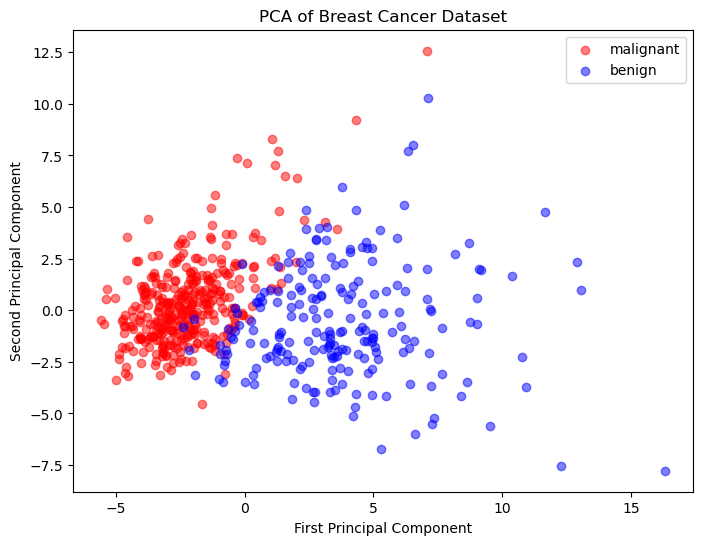

In [42]:
plt.figure(figsize=(8,6))
unique_classes = np.unique(y)
colors = ['red', 'blue']
labels = ['malignant', 'benign']
for i, cls in enumerate(unique_classes):
    plt.scatter(X_pca[y==cls, 0], X_pca[y==cls, 1], 
                color=colors[i], label=labels[i], alpha=0.5)
plt.title('PCA of Breast Cancer Dataset')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend()
plt.show()